In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df = pd.read_csv("USA_Housing.csv")  
df.head(10)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN
5,103378.0,for_sale,179000.0,4.0,3.0,0.46,1850806.0,San Sebastian,Puerto Rico,612.0,2520.0,NaN
6,1205.0,for_sale,50000.0,3.0,1.0,0.20,1298094.0,Ciales,Puerto Rico,639.0,2040.0,NaN
7,50739.0,for_sale,71600.0,3.0,2.0,0.08,1048466.0,Ponce,Puerto Rico,731.0,1050.0,NaN
8,81909.0,for_sale,100000.0,2.0,1.0,0.09,734904.0,Ponce,Puerto Rico,730.0,1092.0,NaN
9,65672.0,for_sale,300000.0,5.0,3.0,7.46,1946226.0,Las Marias,Puerto Rico,670.0,5403.0,NaN


In [28]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)


Shape of dataset: (2226382, 12)

Columns:
 Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date'],
      dtype='object')

Data types:
 brokered_by       float64
status             object
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city               object
state              object
zip_code          float64
house_size        float64
prev_sold_date     object
dtype: object


In [29]:
df.info()

print("Rows & Columns:", df.shape)

print("Missing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB
Rows & Columns: (2226382, 12)
Missing values:
 brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64


In [30]:
df.describe()


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [31]:
df = df.drop_duplicates()
print("Duplicates removed. Shape:", df.shape)


Duplicates removed. Shape: (2226382, 12)


In [32]:
df = df.dropna(how="all")  # drop empty rows
print("Remaining missing values per column:\n", df.isna().sum())


Remaining missing values per column:
 brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64


In [33]:
drop_cols = ["Row ID", "Order ID", "Customer ID", "Product ID", "Country", "Postal Code", "price"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors="ignore")
df.head()


,brokered_by,status,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [34]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include="object").columns
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


In [35]:
numeric_cols = ['bed', 'bath', 'acre_lot', 'house_size']
categorical_cols = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code']

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: ['bed', 'bath', 'acre_lot', 'house_size']
Categorical Columns: ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code']


In [36]:
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')

df['sold_year'] = df['prev_sold_date'].dt.year
df['sold_month'] = df['prev_sold_date'].dt.month

df.drop(columns=['prev_sold_date'], inplace=True)


In [37]:
cat_cols = ['brokered_by', 'status', 'street', 'city', 'state']

for col in cat_cols:
    if col in df.columns:
        freq_encoding = df[col].value_counts().to_dict()
        df[col] = df[col].map(freq_encoding)


In [38]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ['status', 'state']  # safer, limited categories
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)


In [39]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['bed', 'bath', 'acre_lot', 'house_size', 'zip_code']
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


In [40]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df[num_cols] = scaler_std.fit_transform(df[num_cols])


In [41]:
if 'prev_sold_date' in df.columns:
    df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')
    df['prev_sold_year'] = df['prev_sold_date'].dt.year
    df['prev_sold_month'] = df['prev_sold_date'].dt.month
    df['prev_sold_day'] = df['prev_sold_date'].dt.day
    df.drop(columns=['prev_sold_date'], inplace=True)


In [42]:
print("Final shape:", df.shape)
print("Remaining columns:", df.columns.tolist())
df.head()


Final shape: (2226382, 67)
Remaining columns: ['brokered_by', 'bed', 'bath', 'acre_lot', 'street', 'city', 'zip_code', 'house_size', 'sold_year', 'sold_month', 'status_812009', 'status_1389306', 'state_8', 'state_489', 'state_895', 'state_2581', 'state_2600', 'state_3126', 'state_3642', 'state_4039', 'state_4268', 'state_4690', 'state_5065', 'state_6309', 'state_6625', 'state_7243', 'state_8157', 'state_8628', 'state_10059', 'state_12309', 'state_14008', 'state_14557', 'state_14667', 'state_14858', 'state_16255', 'state_16760', 'state_18840', 'state_21074', 'state_23033', 'state_23045', 'state_25815', 'state_26316', 'state_32163', 'state_32293', 'state_34053', 'state_37140', 'state_38041', 'state_40964', 'state_42367', 'state_42390', 'state_42429', 'state_43412', 'state_45145', 'state_46052', 'state_48199', 'state_59207', 'state_62461', 'state_68763', 'state_72825', 'state_78373', 'state_80977', 'state_85280', 'state_85745', 'state_103159', 'state_208335', 'state_227215', 'state_249432

,brokered_by,bed,bath,acre_lot,street,city,zip_code,house_size,sold_year,sold_month,...,state_68763,state_72825,state_78373,state_80977,state_85280,state_85745,state_103159,state_208335,state_227215,state_249432
0,71.0,-0.176000,-0.300405,-0.019799,1.0,2,-1.781638,-0.002220,1970,1,...,False,False,False,False,False,False,False,False,False,False
1,396.0,0.462050,-0.300405,-0.019851,1.0,2,-1.781638,-0.001469,1970,1,...,False,False,False,False,False,False,False,False,False,False
2,20.0,-0.814051,-0.905522,-0.019760,1.0,17,-1.774937,-0.002433,1970,1,...,False,False,False,False,False,False,False,False,False,False
3,8.0,0.462050,-0.300405,-0.019825,1.0,81,-1.777148,-0.001132,1970,1,...,False,False,False,False,False,False,False,False,False,False
4,4.0,1.738152,-0.300405,-0.019891,1.0,64,-1.778909,NaN,1970,1,...,False,False,False,False,False,False,False,False,False,False


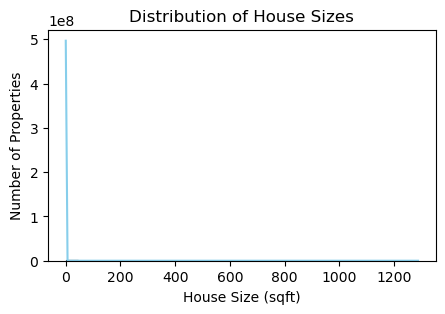

In [43]:
plt.figure(figsize=(5,3))
sns.histplot(df['house_size'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of House Sizes')
plt.xlabel('House Size (sqft)')
plt.ylabel('Number of Properties')
plt.show()


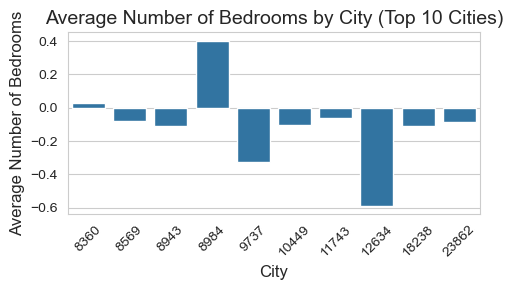

In [57]:
plt.figure(figsize=(5,3))
sns.barplot(x='city', y='bed', data=avg_bedrooms)  # No palette
plt.title('Average Number of Bedrooms by City (Top 10 Cities)', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Number of Bedrooms', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


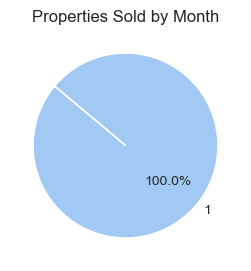

In [55]:
month_counts = df['sold_month'].value_counts().sort_index()
plt.figure(figsize=(5,3))
plt.pie(month_counts, labels=month_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Properties Sold by Month')
plt.show()


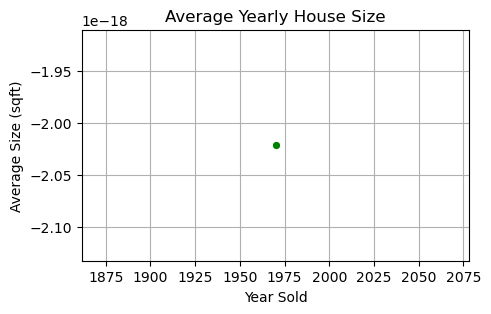

In [46]:
yearly_avg_size = df.groupby('sold_year')['house_size'].mean().reset_index()

plt.figure(figsize=(5,3))
sns.lineplot(x='sold_year', y='house_size', data=yearly_avg_size, marker='o', color='green')
plt.title('Average Yearly House Size')
plt.xlabel('Year Sold')
plt.ylabel('Average Size (sqft)')
plt.grid(True)
plt.show()


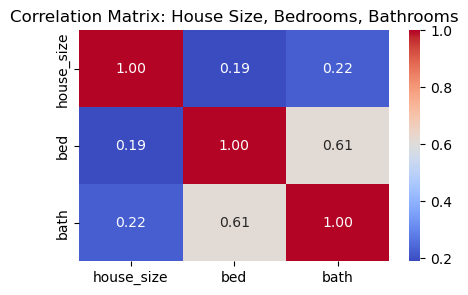

In [47]:
numeric_cols = ['house_size', 'bed', 'bath']
corr = df[numeric_cols].corr()

plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: House Size, Bedrooms, Bathrooms')
plt.show()
